In [2]:
import os
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import nslr_hmm
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy.interpolate import make_interp_spline
from scipy.stats import mannwhitneyu

import config
import data_processing

# Constants

In [3]:
# Color palettes
CUSTOM_PALETTE = {
    'purple': '#673C4F',
    'blue': '#1C77C3',
    'light_blue': '#40BCD8',
    'green': '#68D89B',
    'yellow': '#FDCA40',
    'orange': '#F39237',
    'red': '#D63230'
}
PATH_PALETTE = {
    'straight_path': '#F39237',
    'no_straight_path': '#1C77C3',
    'other': '#68D89B',
    'No straight path': '#1C77C3',
    'Straight path': '#F39237'
}
GAZE_CLASS_COLORS = {
        nslr_hmm.FIXATION: CUSTOM_PALETTE['yellow'],
        nslr_hmm.SACCADE: CUSTOM_PALETTE['red'],
        nslr_hmm.SMOOTH_PURSUIT: CUSTOM_PALETTE['green'],
        nslr_hmm.PSO: CUSTOM_PALETTE['blue'],
        'fixation': CUSTOM_PALETTE['yellow'],
        'saccade': CUSTOM_PALETTE['red'],
        'smooth_pursuit': CUSTOM_PALETTE['green'],
        'pso': CUSTOM_PALETTE['blue'],
        'abstraction': CUSTOM_PALETTE['red'],
        'simulation': CUSTOM_PALETTE['green']
}
GAZE_CLASS_LABELS = {
    nslr_hmm.FIXATION: 'fixation',
    nslr_hmm.SACCADE: 'saccade',
    nslr_hmm.SMOOTH_PURSUIT: 'smooth_pursuit',
    nslr_hmm.PSO: 'pso',
}
# Directory containing the images of each scene; used for plotting
IMG_DIR = '../data/scene_images/'
SAVING_FIGURES = False

In [4]:
# Set the style and context for larger fonts
sns.set_theme(font_scale=1.5)
sns.set_context("paper", rc={
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})
sns.set_style("white")

# Helpers

In [5]:
def assign_path_condition(x):
    """Assigns the path condition for a given scene name."""
    A = 11
    if 'yessp' in x:
        return 'straight_path'
    if 'nosp' in x:
        return 'no_straight_path'
    if 'scene' in x:
        scene_num = int(x.split('_')[1])
        scene_idx = int(x.split('_')[-1])
        if scene_num == 1 and scene_idx <= A:
            return 'straight_path'
        if scene_num == 1 and scene_idx > A:
            return 'no_straight_path'
        if scene_num == 2:
            return 'straight_path'
    raise ValueError

In [6]:
def scene_to_screen_coordinates(scene_coordinate):
    scene_x, scene_y = scene_coordinate
    scene_x_lim = 800
    scene_y_lim = 1000
    screen_x_lim = 1920
    screen_y_lim = 1080
    converted_x = screen_x_lim/2 - scene_x_lim/2 + scene_x
    converted_y = screen_y_lim/2 - scene_y_lim/2 + scene_y
    return [converted_x, converted_y]

# Import and wrangle data

Human gaze data

In [7]:
# Get raw human gaze data
raw_trial_gaze_data = data_processing.import_gaze_data(
    data_dir=os.path.join('..', config.DATA_DIR, 'experiment1'))

Processing ASC files: 100%|██████████| 12/12 [00:19<00:00,  1.66s/it]


Subsetting relevant data and cleaning the subset

In [8]:
# Only care about the trials where participants are inferring the trajectory
trial_gaze_data = data_processing.get_intra_trial_data(raw_trial_gaze_data)
# Remove out-of-bounds gaze positions
trial_gaze_data = data_processing.remove_impossible_values(trial_gaze_data)
# Remove pre-lockon gaze data
trial_gaze_data = data_processing.remove_pre_lockon(trial_gaze_data, 100)

In [9]:
# Remove columns that are not needed for the analysis
trial_gaze_data = trial_gaze_data.drop(
    columns=[
        'subject_treatment',
        'block_index',
        'block_duration',
        'ball_start_position',
        'button_response'])

In [10]:
# Rename the time column to raw_time
trial_gaze_data = trial_gaze_data.rename(columns={'time': 'raw_time'})
# Normalize raw_time (ms) to the start of the trial for each subject and scene
trial_gaze_data['raw_time'] = trial_gaze_data.groupby(
    ['subject_id', 'scene_name']).raw_time.transform(lambda x: x - x.min())

In [11]:
trial_gaze_data['normalized_time'] = trial_gaze_data.groupby(
    ['subject_id', 'scene_name']).raw_time.transform(lambda x: x * 1000)
trial_gaze_data['normalized_time'] = trial_gaze_data.normalized_time.apply(
    lambda x: round(x))

In [12]:
trial_gaze_data['path'] = trial_gaze_data['scene_name'].transform(assign_path_condition)

Subsetting visual search data

In [13]:
visual_search_data = raw_trial_gaze_data[
    raw_trial_gaze_data.scene_name.str.contains('_pre')]
visual_search_data.scene_name = visual_search_data.scene_name.apply(
    lambda x: x.replace('_pre', ''))
visual_search_data = visual_search_data[
    ~visual_search_data.scene_name.str.contains('comprehension')]

In [14]:
# Remove columns that are not needed for the analysis
visual_search_data = visual_search_data.drop(
    columns=[
        'subject_treatment',
        'block_index',
        'block_duration',
        'button_response'])

In [15]:
# Rename the time column to raw_time
visual_search_data = visual_search_data.rename(columns={'time': 'raw_time'})
# Normalize raw_time (ms) to the start of the trial for each subject and scene
visual_search_data['raw_time'] = visual_search_data.groupby(
    ['subject_id', 'scene_name']).raw_time.transform(lambda x: x - x.min())

In [16]:
visual_search_data['normalized_time'] = visual_search_data.groupby(
    ['subject_id', 'scene_name']).raw_time.transform(lambda x: x * 1000)
visual_search_data['normalized_time'] = visual_search_data.normalized_time.apply(
    lambda x: round(x))

# NSLR classification

Classifying gaze lines according to linear models of saccades, fixations, smoth pursuits, or post-saccadic oscillations

In [17]:
# Group by subject and scene
grouped = trial_gaze_data.groupby(['subject_id', 'scene_name'])
# Create a dataframe to store results
nslr_results = {
        'subject_id': [],
        'scene_name': [],
        'segmentation': [],
        'segment_classes': [],
    }
# Classify
for (subject, scene), group in grouped:
    # Sort by trajectory_idx to ensure correct order
    group = group.sort_values('normalized_time')    
    # Extract x, y, and time columns
    x = group['x'].values
    y = group['y'].values
    t = group['raw_time'].values
    gaze = [(_x, _y) for _x, _y in zip(x, y)]
    # gaze = np.vstack((x, y)).T
    # Create segmenations and classifications of those segments
    sample_class, segmentation, seg_class = nslr_hmm.classify_gaze(
        ts=t, xs=gaze)
    nslr_results['subject_id'].append(subject)
    nslr_results['scene_name'].append(scene)
    nslr_results['segmentation'].append(segmentation)
    nslr_results['segment_classes'].append(seg_class)
gaze_classifications = pd.DataFrame.from_dict(nslr_results, orient='columns')

In [18]:
# Group by subject and scene
grouped = visual_search_data.groupby(['subject_id', 'scene_name'])
# Create a dataframe to store results
nslr_results = {
        'subject_id': [],
        'scene_name': [],
        'segmentation': [],
        'segment_classes': [],
    }
# Classify
for (subject, scene), group in grouped:
    # Sort by trajectory_idx to ensure correct order
    group = group.sort_values('normalized_time')    
    # Extract x, y, and time columns
    x = group['x'].values
    y = group['y'].values
    t = group['raw_time'].values
    gaze = [(_x, _y) for _x, _y in zip(x, y)]
    # gaze = np.vstack((x, y)).T
    # Create segmenations and classifications of those segments
    sample_class, segmentation, seg_class = nslr_hmm.classify_gaze(
        ts=t, xs=gaze)
    nslr_results['subject_id'].append(subject)
    nslr_results['scene_name'].append(scene)
    nslr_results['segmentation'].append(segmentation)
    nslr_results['segment_classes'].append(seg_class)
search_classifications = pd.DataFrame.from_dict(nslr_results, orient='columns')

In [19]:
# Create a list to store segment data
segment_data = []
# Each row is a tuple of subject, scene, gaze segments, and segment classes
for _, row in gaze_classifications.iterrows():
    segments = row['segmentation']
    segment_classes = row['segment_classes']
    subject_id = row['subject_id']
    scene_name = row['scene_name']
    # Extract segment information
    for idx, (gaze_segment, segment_class) in enumerate(
        zip(segments.segments, segment_classes)):
        start_idx, end_idx = gaze_segment.i
        start_time, end_time = gaze_segment.t
        start_point, end_point = gaze_segment.x
        # Add to our data collection
        segment_data.append({
            'subject_id': subject_id,
            'scene_name': scene_name,
            'segment_class': GAZE_CLASS_LABELS[segment_class],
            'segment_idx': idx,
            'start_x': start_point[0],
            'end_x': end_point[0],
            'start_y': start_point[1],
            'end_y': end_point[1],
            'start_time': start_time,
            'end_time': end_time,
            'normalized_start_time': round(start_time * 1000),
            'normalized_end_time': round(end_time * 1000),
        })
# Create a DataFrame from the segment data
gaze_segments = pd.DataFrame(segment_data)

In [20]:
# Create a list to store segment data
segment_data = []
# Each row is a tuple of subject, scene, gaze segments, and segment classes
for _, row in search_classifications.iterrows():
    segments = row['segmentation']
    segment_classes = row['segment_classes']
    subject_id = row['subject_id']
    scene_name = row['scene_name']
    # Extract segment information
    for idx, (gaze_segment, segment_class) in enumerate(
        zip(segments.segments, segment_classes)):
        start_idx, end_idx = gaze_segment.i
        start_time, end_time = gaze_segment.t
        start_point, end_point = gaze_segment.x
        # Add to our data collection
        segment_data.append({
            'subject_id': subject_id,
            'scene_name': scene_name,
            'segment_class': GAZE_CLASS_LABELS[segment_class],
            'segment_idx': idx,
            'start_x': start_point[0],
            'end_x': end_point[0],
            'start_y': start_point[1],
            'end_y': end_point[1],
            'start_time': start_time,
            'end_time': end_time,
            'normalized_start_time': round(start_time * 1000),
            'normalized_end_time': round(end_time * 1000),
        })
# Create a DataFrame from the segment data
search_segments = pd.DataFrame(segment_data)

In [21]:
# Setting path condition, search_segments don't need this variable
gaze_segments['path_condition'] = gaze_segments['scene_name'].apply(assign_path_condition)
gaze_segments['trial'] = 'reasoning'
search_segments['path_condition'] = search_segments['scene_name'].apply(assign_path_condition)
search_segments['trial'] = 'search'

In [22]:
gaze_segments = gaze_segments.assign(
    normalized_time=lambda d: [
        list(range(int(s), int(e)))
        for s, e in zip(d.normalized_start_time, d.normalized_end_time)
        ]
    ).explode("normalized_time", ignore_index=True)
gaze_segments.drop(
    columns=[
        'normalized_start_time',
        'normalized_end_time',
        'start_time',
        'end_time'
    ], inplace=True)
gaze_segments.head()

,subject_id,scene_name,segment_class,segment_idx,start_x,end_x,start_y,end_y,path_condition,trial,normalized_time
0,1d4c760f,high_nocol_nosp_1,fixation,0,716.442511,675.232466,438.331433,495.805702,no_straight_path,reasoning,0
1,1d4c760f,high_nocol_nosp_1,fixation,0,716.442511,675.232466,438.331433,495.805702,no_straight_path,reasoning,1
2,1d4c760f,high_nocol_nosp_1,fixation,0,716.442511,675.232466,438.331433,495.805702,no_straight_path,reasoning,2
3,1d4c760f,high_nocol_nosp_1,fixation,0,716.442511,675.232466,438.331433,495.805702,no_straight_path,reasoning,3
4,1d4c760f,high_nocol_nosp_1,fixation,0,716.442511,675.232466,438.331433,495.805702,no_straight_path,reasoning,4


In [23]:
search_segments = search_segments.assign(
    normalized_time=lambda d: [
        list(range(int(s), int(e)))
        for s, e in zip(d.normalized_start_time, d.normalized_end_time)
        ]
    ).explode("normalized_time", ignore_index=True)
search_segments.drop(
    columns=[
        'normalized_start_time',
        'normalized_end_time',
        'start_time',
        'end_time'
    ], inplace=True)
search_segments.head()

,subject_id,scene_name,segment_class,segment_idx,start_x,end_x,start_y,end_y,path_condition,trial,normalized_time
0,1d4c760f,high_nocol_nosp_1,saccade,0,861.159749,862.00128,461.574384,459.000494,no_straight_path,search,0
1,1d4c760f,high_nocol_nosp_1,saccade,0,861.159749,862.00128,461.574384,459.000494,no_straight_path,search,1
2,1d4c760f,high_nocol_nosp_1,saccade,0,861.159749,862.00128,461.574384,459.000494,no_straight_path,search,2
3,1d4c760f,high_nocol_nosp_1,saccade,0,861.159749,862.00128,461.574384,459.000494,no_straight_path,search,3
4,1d4c760f,high_nocol_nosp_1,saccade,0,861.159749,862.00128,461.574384,459.000494,no_straight_path,search,4


In [24]:
all_segments = pd.concat([gaze_segments, search_segments])

In [25]:
indices = list(gaze_segments.normalized_time.astype(int))
classified_trial_data = trial_gaze_data.groupby(
    ['subject_id', 'scene_name']).nth(indices)
classified_trial_data = classified_trial_data.merge(
    gaze_segments,
    on=['subject_id', 'scene_name', 'normalized_time'],
)[[
    'subject_id',
    'scene_name',
    'normalized_time',
    'segment_class',
    'x',
    'y',
    'pupil',
    'path_condition',
    'raw_time',
    'trial'
]]

In [26]:
indices = list(gaze_segments.normalized_time.astype(int))
classified_search_data = visual_search_data.groupby(
    ['subject_id', 'scene_name']).nth(indices)
classified_search_data = classified_search_data.merge(
    search_segments,
    on=['subject_id', 'scene_name', 'normalized_time'],
    how='inner'
)[[
    'subject_id',
    'scene_name',
    'normalized_time',
    'segment_class',
    'x',
    'y',
    'pupil',
    'path_condition',
    'raw_time',
    'trial'
]]

In [27]:
classified_all_gaze_data = pd.concat([
    classified_trial_data,
    classified_search_data
])
classified_all_gaze_data.head()

,subject_id,scene_name,normalized_time,segment_class,x,y,pupil,path_condition,raw_time,trial
0,1d4c760f,high_nocol_nosp_1,0,fixation,715.9,440.5,1847.0,no_straight_path,0.000,reasoning
1,1d4c760f,high_nocol_nosp_1,1,fixation,705.8,452.2,1848.0,no_straight_path,0.001,reasoning
2,1d4c760f,high_nocol_nosp_1,2,fixation,696.5,465.2,1850.0,no_straight_path,0.002,reasoning
3,1d4c760f,high_nocol_nosp_1,3,fixation,687.4,478.0,1853.0,no_straight_path,0.003,reasoning
4,1d4c760f,high_nocol_nosp_1,4,fixation,679.5,490.9,1854.0,no_straight_path,0.004,reasoning


In [28]:
classified_trial_data[['x_int','y_int']] = classified_trial_data[['x','y']].astype(int)

In [29]:
segment_map_data = classified_trial_data.groupby(
    ['x_int', 'y_int', 'scene_name']).segment_class.agg(
        lambda x: x.value_counts().idxmax())
segment_map_data = segment_map_data.reset_index()
segment_map_data.head()

,x_int,y_int,scene_name,segment_class
0,349,1021,med_nocol_yessp_2,saccade
1,353,1014,med_nocol_yessp_2,saccade
2,358,1078,med_nocol_yessp_4,saccade
3,365,998,med_nocol_yessp_2,saccade
4,370,1061,med_nocol_yessp_4,saccade


In [30]:
mean_segment_gaze_data = pd.DataFrame(
    classified_trial_data.groupby(['scene_name', 'normalized_time']).agg({
        'x_int': 'mean',
        'y_int': 'mean', 
        'segment_class': lambda x: x.mode().iloc[0],
        'pupil': 'mean'
    })).reset_index()
mean_segment_gaze_data['pupil_log'] = mean_segment_gaze_data.pupil.apply(np.log)
mean_segment_gaze_data.head(20)

,scene_name,normalized_time,x_int,y_int,segment_class,pupil,pupil_log
0,high_nocol_nosp_1,0,735.454545,445.363636,fixation,1149.545455,7.047122
1,high_nocol_nosp_1,1,729.636364,448.727273,fixation,1149.363636,7.046964
2,high_nocol_nosp_1,2,724.363636,452.272727,fixation,1149.727273,7.047280
3,high_nocol_nosp_1,3,720.272727,455.545455,saccade,1150.909091,7.048307
4,high_nocol_nosp_1,4,716.636364,458.454545,saccade,1151.818182,7.049097
5,high_nocol_nosp_1,5,713.909091,461.181818,saccade,1152.181818,7.049413
6,high_nocol_nosp_1,6,711.818182,463.636364,saccade,1152.000000,7.049255
7,high_nocol_nosp_1,7,710.454545,465.909091,saccade,1151.636364,7.048939
8,high_nocol_nosp_1,8,709.818182,468.090909,saccade,1151.545455,7.048860
9,high_nocol_nosp_1,9,709.727273,469.454545,saccade,1151.727273,7.049018


In [31]:
segment_map_data = classified_trial_data.groupby(
    ['x_int', 'y_int', 'scene_name']).segment_class.agg(
        lambda x: x.value_counts().idxmax())
segment_map_data = segment_map_data.reset_index()
segment_map_data.head()

,x_int,y_int,scene_name,segment_class
0,349,1021,med_nocol_yessp_2,saccade
1,353,1014,med_nocol_yessp_2,saccade
2,358,1078,med_nocol_yessp_4,saccade
3,365,998,med_nocol_yessp_2,saccade
4,370,1061,med_nocol_yessp_4,saccade


# Visualizing

Plotting the proportion of segment classes (saccade and smooth pursuit)

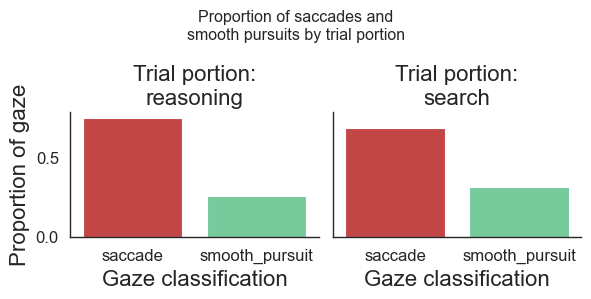

In [30]:
sac_sp_segments = all_segments[
        (all_segments['segment_class'].isin(['saccade', 'smooth_pursuit']))]
g = sns.FacetGrid(
    data=sac_sp_segments,
    col='trial',
)
g.map_dataframe(sns.countplot,
    data=sac_sp_segments,
    x='segment_class',
    hue='segment_class',
    palette=GAZE_CLASS_COLORS,
    stat='proportion',
)
g.set_titles('Trial portion:\n{col_name}')
g.set_xlabels('Gaze classification')
g.set_ylabels('Proportion of gaze')
g.fig.suptitle('Proportion of saccades and\nsmooth pursuits by trial portion')
plt.tight_layout()
g.figure.savefig(f'../{config.DATA_DIR}/figures/gaze_label_proportions.pdf')

Plotting histograms of gaze data colored by event classification (i.e. if x-y is
from a saccade or smooth pursuit))

In [34]:
# Create heatmap for first scene
for scene in trial_gaze_data['scene_name'].unique():
    scene_gaze_data = trial_gaze_data[trial_gaze_data['scene_name'] == scene]
    scene_gaze_data['y'] = 1080 - scene_gaze_data['y']
    scene_segment_data = gaze_segments[gaze_segments['scene_name'] == scene]
    
    saccade_data = scene_segment_data[
        scene_segment_data['segment_class'] == 'saccade']
    saccade_indices = list(saccade_data.normalized_time.astype(int))
    saccade_data = scene_gaze_data.groupby(
        ['subject_id', 'scene_name']).nth(saccade_indices)

    smooth_pursuit_data = scene_segment_data[
        scene_segment_data['segment_class'] == 'smooth_pursuit']
    smooth_pursuit_indices = list(
        smooth_pursuit_data.normalized_time.astype(int))
    smooth_pursuit_data = scene_gaze_data.groupby(
        ['subject_id', 'scene_name']).nth(smooth_pursuit_indices)

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    ax.imshow(img,extent=(560, 1360, 40, 1040), aspect='auto')
    g = sns.histplot(
        data=smooth_pursuit_data,
        x='x',
        y='y',
        alpha=0.7,
        color=GAZE_CLASS_COLORS['smooth_pursuit'])
    g = sns.histplot(
        data=saccade_data,
        x='x',
        y='y',
        alpha=0.7,
        color=GAZE_CLASS_COLORS['saccade'])
    g.set_title(f'{scene}')
    g.set_xlabel('x')
    g.set_ylabel('y')
    g.set_xlim(0, 1920)
    g.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/gaze_segment_map_{scene}.pdf',
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.1)
    plt.close()


Looking at how pupil varies across gaze classification

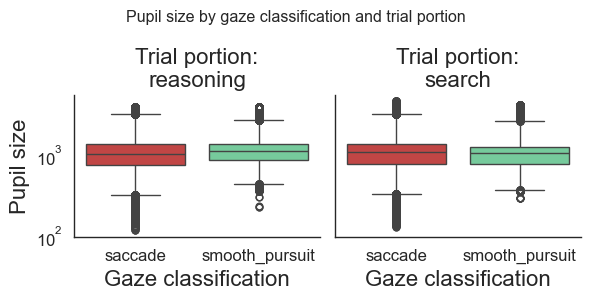

In [36]:
sac_sp_data = classified_all_gaze_data[
    (classified_all_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit']))]
g = sns.FacetGrid(
    data=sac_sp_data,
    col='trial',
)
g.map_dataframe(sns.boxplot,
    data=sac_sp_data,
    x='segment_class',
    y='pupil',
    hue='segment_class',
    palette=GAZE_CLASS_COLORS,
    log_scale=True,
)
g.set_titles('Trial portion:\n{col_name}')
g.set_xlabels('Gaze classification')
g.set_ylabels('Pupil size')
g.fig.suptitle('Pupil size by gaze classification and trial portion')
plt.tight_layout()
g.figure.savefig(f'../{config.DATA_DIR}/figures/boxplot_pupil_trial_portion.pdf')
plt.show()

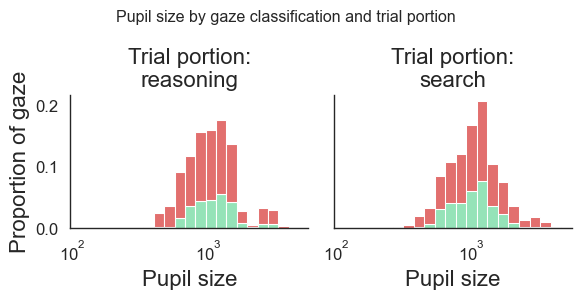

In [37]:
sac_sp_data = classified_all_gaze_data[
    (classified_all_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit']))]
g = sns.FacetGrid(
    data=sac_sp_data,
    col='trial',
)
g.map_dataframe(sns.histplot,
    data=sac_sp_data,
    x='pupil',
    hue='segment_class',
    palette=GAZE_CLASS_COLORS,
    alpha=0.7,
    stat='proportion',
    multiple='stack',
    bins=20,
    log_scale=True,
)
g.set_titles('Trial portion:\n{col_name}')
g.set_xlabels('Pupil size')
g.set_ylabels('Proportion of gaze')
g.fig.suptitle('Pupil size by gaze classification and trial portion')
plt.tight_layout()
g.figure.savefig(f'../{config.DATA_DIR}/figures/histplot_pupil_trial_portion.pdf')
plt.show()

In [38]:
# Test for sigdiff
pupil_saccade = classified_all_gaze_data[
    classified_all_gaze_data['segment_class'] == 'saccade']['pupil']
pupil_smooth = classified_all_gaze_data[
    classified_all_gaze_data['segment_class'] == 'smooth_pursuit']['pupil']

stat, p = mannwhitneyu(pupil_smooth, pupil_saccade, alternative='greater')
print(f"Mann-Whitney U test reasoning: statistic={stat:.2f}, p-value={p:.4g}")

Mann-Whitney U test reasoning: statistic=1594234561107.50, p-value=5.81e-298


In [39]:
# Test for sigdiff
pupil_saccade = classified_trial_data[
    classified_trial_data['segment_class'] == 'saccade']['pupil']
pupil_smooth = classified_trial_data[
    classified_trial_data['segment_class'] == 'smooth_pursuit']['pupil']

stat, p = mannwhitneyu(pupil_smooth, pupil_saccade, alternative='greater')
print(f"Mann-Whitney U test reasoning: statistic={stat:.2f}, p-value={p:.4g}")

Mann-Whitney U test reasoning: statistic=350151118944.50, p-value=0


In [40]:
# Test for sigdiff
pupil_saccade = classified_search_data[
    classified_search_data['segment_class'] == 'saccade']['pupil']
pupil_smooth = classified_search_data[
    classified_search_data['segment_class'] == 'smooth_pursuit']['pupil']

stat, p = mannwhitneyu(pupil_smooth, pupil_saccade, alternative='greater')
print(f"Mann-Whitney U test search: statistic={stat:.2f}, p-value={p:.4g}")

Mann-Whitney U test search: statistic=447145376667.50, p-value=1


Plotting gaze lines

In [32]:
mean_gaze_data = pd.DataFrame(
    classified_trial_data.groupby(
        ['scene_name',
        'normalized_time',
        'segment_class'])[['x','y']].mean()).reset_index()
mean_gaze_data.head()

,scene_name,normalized_time,segment_class,x,y
0,high_nocol_nosp_1,0,fixation,754.871429,450.985714
1,high_nocol_nosp_1,0,saccade,702.425000,436.850000
2,high_nocol_nosp_1,1,fixation,746.514286,455.928571
3,high_nocol_nosp_1,1,saccade,701.175000,437.575000
4,high_nocol_nosp_1,2,fixation,738.557143,461.100000


In [42]:
sac_sp_data = mean_gaze_data[
    mean_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit'])]
for scene in sac_sp_data['scene_name'].unique():
    scene_gaze_data = sac_sp_data[sac_sp_data['scene_name'] == scene]
    scene_gaze_data['y'] = 1080 - scene_gaze_data['y']
    scene_gaze_data = scene_gaze_data.groupby(
        [
            'scene_name',
            'segment_class'
        ]).rolling(
            window=200,
            min_periods=1,
            on='normalized_time'
        )[['x','y']].mean().reset_index()

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    ax.imshow(img,extent=(560, 1360, 40, 1040), aspect='auto')
    g = sns.histplot(
        data=scene_gaze_data,
        x='x',
        y='y',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.7,
    )
    g.set_title(f'{scene}')
    g.set_xlabel('x')
    g.set_ylabel('y')
    g.set_xlim(0, 1920)
    g.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/mean_gaze_segment_map_{scene}.pdf',
        dpi=300,
        bbox_inches='tight')
    plt.close()

In [33]:
segment_map_data = classified_trial_data.groupby(
    ['x_int', 'y_int', 'scene_name', 'normalized_time']
).segment_class.agg(lambda s: s.value_counts().idxmax()).reset_index()
segment_map_data.head()

,x_int,y_int,scene_name,normalized_time,segment_class
0,349,1021,med_nocol_yessp_2,246,saccade
1,349,1021,med_nocol_yessp_2,247,saccade
2,353,1014,med_nocol_yessp_2,248,saccade
3,358,1078,med_nocol_yessp_4,629,saccade
4,365,998,med_nocol_yessp_2,249,saccade


In [45]:
for scene in segment_map_data['scene_name'].unique():
    scene_gaze_data = segment_map_data[segment_map_data['scene_name'] == scene]
    scene_gaze_data = scene_gaze_data[
        scene_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit'])]
    scene_gaze_data['y_int'] = 1080 - scene_gaze_data['y_int']
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    g = sns.histplot(
        data=scene_gaze_data,
        x='x_int',
        y='y_int',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.6,
        ax=ax,
    )
    ax.imshow(img, extent=(560, 1360, 40, 1040), aspect='auto')
    g.set_title(f'{scene}')
    g.set_xlabel('x')
    g.set_ylabel('y')
    g.set_xlim(0, 1920)
    g.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/top_segment_map_{scene}.pdf',
        dpi=300,
        bbox_inches='tight')
    plt.close()

In [46]:
for scene in mean_segment_gaze_data['scene_name'].unique():
    scene_gaze_data = mean_segment_gaze_data[mean_segment_gaze_data['scene_name'] == scene]
    scene_gaze_data = scene_gaze_data[
        scene_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit'])]
    scene_gaze_data['y_int'] = 1080 - scene_gaze_data['y_int']
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    g = sns.histplot(
        data=scene_gaze_data,
        x='x_int',
        y='y_int',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.6,
        ax=ax,
    )
    ax.imshow(img, extent=(560, 1360, 40, 1040), aspect='auto')
    g.set_title(f'{scene}')
    g.set_xlabel('x')
    g.set_ylabel('y')
    g.set_xlim(0, 1920)
    g.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/top_mean_segment_map_{scene}.pdf',
        dpi=300,
        bbox_inches='tight')
    plt.close()

In [47]:
bins = 200
x_edges = np.linspace(0, 1920, bins+1)
y_edges = np.linspace(0, 1080, bins+1)

for scene in mean_segment_gaze_data['scene_name'].unique():
    scene_gaze_data = mean_segment_gaze_data[
        (mean_segment_gaze_data['scene_name'] == scene) &
        (mean_segment_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit']))
    ].copy()
    scene_gaze_data['y_int'] = 1080 - scene_gaze_data['y_int']

    x = scene_gaze_data['x_int'].to_numpy()
    y = scene_gaze_data['y_int'].to_numpy()
    w = scene_gaze_data['pupil_log'].to_numpy()

    W, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges], weights=w)
    C, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    M = np.divide(W, C, out=np.full_like(W, np.nan, dtype=float), where=C>0)

    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    ax.imshow(img, extent=(560, 1360, 40, 1040), aspect='auto', zorder=0)

    im = ax.imshow(
        M.T,
        origin='lower',
        extent=[0, 1920, 0, 1080],
        cmap='viridis',
        alpha=0.7,
        zorder=1,
        aspect='auto'
    )
    cbar = fig.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label('Mean pupil diameter (log)')

    ax.set_title(f"{scene}")
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(0, 1920); ax.set_ylim(0, 1080)

    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/mean_pupil_log_np_{scene}.pdf',
        dpi=300, bbox_inches='tight'
    )
    plt.close()


In [34]:
mean_segment_gaze_data['pupil_count'] = mean_segment_gaze_data.pupil.transform(
    lambda x: np.log(x-x.min()+1))
mean_segment_gaze_data.head()

,scene_name,normalized_time,x_int,y_int,segment_class,pupil,pupil_log,pupil_count
0,high_nocol_nosp_1,0,735.454545,445.363636,fixation,1149.545455,7.047122,6.536757
1,high_nocol_nosp_1,1,729.636364,448.727273,fixation,1149.363636,7.046964,6.536494
2,high_nocol_nosp_1,2,724.363636,452.272727,fixation,1149.727273,7.047280,6.537021
3,high_nocol_nosp_1,3,720.272727,455.545455,saccade,1150.909091,7.048307,6.538732
4,high_nocol_nosp_1,4,716.636364,458.454545,saccade,1151.818182,7.049097,6.540046


In [120]:
# ROI and binning
XMIN, XMAX = 560, 1360
YMIN, YMAX = 0, 1040
BIN = 20  # increase for fewer arrows

for scene in mean_segment_gaze_data['scene_name'].unique():
    scene_data = mean_segment_gaze_data[
        mean_segment_gaze_data['scene_name'] == scene].copy()
    scene_data = scene_data[
        scene_data['segment_class'].isin(['saccade', 'smooth_pursuit'])]
    scene_data['y_int'] = 1080 - scene_data['y_int']
    # 1) sort and compute per-subject diffs (apparent motion)
    scene_data = scene_data.sort_values(
        ['scene_name', 'normalized_time'])
    scene_data['dx'] = scene_data.groupby(
        ['scene_name'])['x_int'].diff()
    scene_data['dy'] = scene_data.groupby(
        ['scene_name'])['y_int'].diff()
    # 2) integer pixel coords (already present as x_int,y_int in your df)
    #    keep only rows with movement defined and within ROI
    flow_df = scene_data.dropna(subset=['dx', 'dy']).copy()
    flow_df = flow_df[
        (flow_df['x_int'].between(XMIN, XMAX)) &
        (flow_df['y_int'].between(YMIN, YMAX))
    ].copy()
    if flow_df.empty:
        continue
    # 3) coarse bin centers for stable arrows + majority class per bin
    flow_df['xb'] = ((flow_df['x_int'] - XMIN) // BIN) * BIN + XMIN + BIN // 2
    flow_df['yb'] = ((flow_df['y_int'] - YMIN) // BIN) * BIN + YMIN + BIN // 2
    agg = (
        flow_df.groupby(['xb', 'yb'])
               .agg(
                   dx=('dx', 'mean'),
                   dy=('dy', 'mean'),
                   segment_class=('segment_class', lambda s: s.value_counts().idxmax()),
                   n=('dx', 'size')
               )
               .reset_index()
    )
    # (optional) drop tiny bins to reduce noise
    agg = agg[agg['n'] >= 3]  # tweak or remove
    # 4) plot
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    ax.imshow(img, extent=(XMIN, XMAX, YMIN, YMAX), aspect='auto')
    # colored bin centers give the legend by segment_class
    sns.scatterplot(
        data=agg, x='xb', y='yb',
        hue='segment_class', palette=GAZE_CLASS_COLORS,
        s=10, ax=ax, legend=True
    )
    # arrows show average motion per bin (kept a single color for simplicity)
    ax.quiver(
        agg['xb'], agg['yb'], agg['dx'], agg['dy'],
        angles='xy', scale_units='xy', scale=0.2, width=0.0025,
        color=agg['segment_class'].map(GAZE_CLASS_COLORS)
    )
    ax.set_title(f'{scene}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_xlim(0, 1920)
    ax.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/top_mean_segment_optic_flow_{scene}.pdf',
        dpi=300, bbox_inches='tight'
    )
    plt.close()


# Model plotting

In [35]:
model_predictions = pd.read_json('../data/blended_results.json')
model_predictions.head()

,scene_name,trajectory,trajectory_idx,reasoning_trace,sample_idx
0,med_nocol_nosp_1,"[[320.0, 248.10777616081785], [320.00485211584...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[simulation, abstraction, abstraction, simulat...",0
1,med_nocol_nosp_1,"[[320.0, 248.10777616081785], [319.99938705333...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[simulation, abstraction, abstraction, simulat...",1
2,med_nocol_nosp_1,"[[320.0, 248.10777616081785], [320.01997863318...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[simulation, abstraction, abstraction, simulat...",2
3,med_nocol_nosp_1,"[[320.0, 248.10777616081785], [320.00887234232...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[simulation, abstraction, abstraction, simulat...",3
4,med_nocol_nosp_1,"[[320.0, 248.10777616081785], [319.97434190989...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[simulation, abstraction, abstraction, simulat...",4


In [36]:
model_predictions = model_predictions.explode(
    ['trajectory', 'trajectory_idx', 'reasoning_trace']
).assign(
    x=lambda df: df['trajectory'].str[0].astype(float),
    y=lambda df: df['trajectory'].str[1].astype(float)
).drop(columns=['trajectory'])
model_predictions = model_predictions.rename(
    columns={
        'trajectory_idx': 'normalized_time',
        'reasoning_trace': 'segment_class'
    }
)

model_predictions.head()

,scene_name,normalized_time,segment_class,sample_idx,x,y
0,med_nocol_nosp_1,0,simulation,0,320.000000,248.107776
0,med_nocol_nosp_1,1,abstraction,0,320.004852,254.961072
0,med_nocol_nosp_1,2,abstraction,0,490.179509,314.627123
0,med_nocol_nosp_1,3,simulation,0,490.180571,314.632069
0,med_nocol_nosp_1,4,simulation,0,490.180568,314.715403


In [37]:
# Create start_x, start_y, end_x, end_y columns for abstraction and simulation segments
test = model_predictions.assign(
    start_x=lambda df: df.groupby(['scene_name', 'sample_idx'])['x'].shift(1).where(
        df['segment_class'].isin(['abstraction', 'simulation']), df['x']
    ),
    start_y=lambda df: df.groupby(['scene_name', 'sample_idx'])['y'].shift(1).where(
        df['segment_class'].isin(['abstraction', 'simulation']), df['y']
    ),
    end_x=lambda df: df['x'].where(df['segment_class'].isin(['abstraction', 'simulation']), df['x']),
    end_y=lambda df: df['y'].where(df['segment_class'].isin(['abstraction', 'simulation']), df['y'])
)
test.head()

,scene_name,normalized_time,segment_class,sample_idx,x,y,start_x,start_y,end_x,end_y
0,med_nocol_nosp_1,0,simulation,0,320.000000,248.107776,NaN,NaN,320.000000,248.107776
0,med_nocol_nosp_1,1,abstraction,0,320.004852,254.961072,320.000000,248.107776,320.004852,254.961072
0,med_nocol_nosp_1,2,abstraction,0,490.179509,314.627123,320.004852,254.961072,490.179509,314.627123
0,med_nocol_nosp_1,3,simulation,0,490.180571,314.632069,490.179509,314.627123,490.180571,314.632069
0,med_nocol_nosp_1,4,simulation,0,490.180568,314.715403,490.180571,314.632069,490.180568,314.715403


In [38]:
# Interpolate only abstraction, copy end values for simulation
exploded_test = test.assign(
    x=lambda df: df.apply(
        lambda row: list(np.linspace(row['start_x'], row['end_x'], 100)) 
        if row['segment_class'] == 'abstraction' 
        else [row['x']], axis=1
    ),
    y=lambda df: df.apply(
        lambda row: list(np.linspace(row['start_y'], row['end_y'], 100)) 
        if row['segment_class'] == 'abstraction' 
        else [row['y']], axis=1
    )
).explode(['x', 'y'])
exploded_test.head()

,scene_name,normalized_time,segment_class,sample_idx,x,y,start_x,start_y,end_x,end_y
0,med_nocol_nosp_1,0,simulation,0,320.0,248.107776,NaN,NaN,320.000000,248.107776
0,med_nocol_nosp_1,1,abstraction,0,320.0,248.107776,320.0,248.107776,320.004852,254.961072
0,med_nocol_nosp_1,1,abstraction,0,320.000049,248.177001,320.0,248.107776,320.004852,254.961072
0,med_nocol_nosp_1,1,abstraction,0,320.000098,248.246227,320.0,248.107776,320.004852,254.961072
0,med_nocol_nosp_1,1,abstraction,0,320.000147,248.315452,320.0,248.107776,320.004852,254.961072


In [39]:
test_segments = gaze_segments[gaze_segments.segment_class.isin(['saccade', 'smooth_pursuit'])]
test_segments.head()

,subject_id,scene_name,segment_class,segment_idx,start_x,end_x,start_y,end_y,path_condition,trial,normalized_time
5,1d4c760f,high_nocol_nosp_1,saccade,1,675.232466,645.414620,495.805702,536.258662,no_straight_path,reasoning,5
6,1d4c760f,high_nocol_nosp_1,saccade,1,675.232466,645.414620,495.805702,536.258662,no_straight_path,reasoning,6
7,1d4c760f,high_nocol_nosp_1,saccade,1,675.232466,645.414620,495.805702,536.258662,no_straight_path,reasoning,7
8,1d4c760f,high_nocol_nosp_1,saccade,1,675.232466,645.414620,495.805702,536.258662,no_straight_path,reasoning,8
9,1d4c760f,high_nocol_nosp_1,saccade,2,645.414620,637.215195,536.258662,557.958664,no_straight_path,reasoning,9


In [40]:
exploded_test[['x', 'y']] = exploded_test.apply(
    lambda row: scene_to_screen_coordinates((row['x'], row['y'])), 
    axis=1,
    result_type='expand'
)

In [41]:
for scene in exploded_test['scene_name'].unique():
    scene_model_preds = exploded_test[
        (exploded_test['scene_name'] == scene)]
    if scene_model_preds.empty:
        print(f'No model predictions for {scene}')
        continue
    scene_model_preds['y'] = 1080 - scene_model_preds['y']
    scene_segment_data = mean_segment_gaze_data[
        (mean_segment_gaze_data['scene_name'] == scene)
        & (mean_segment_gaze_data['segment_class'].isin(['saccade', 'smooth_pursuit']))
    ]
    scene_segment_data['y_int'] = 1080 - scene_segment_data['y_int']
    fig, ax = plt.subplots(figsize=(16, 9))
    img = plt.imread(f'{IMG_DIR}/{scene}.png')
    g = sns.histplot(
        data=scene_segment_data,
        x='x_int',
        y='y_int',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.6,
        ax=ax,
    )
    g = sns.scatterplot(
        data=scene_model_preds[scene_model_preds['segment_class'] == 'abstraction'],
        x='x',
        y='y',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.6,
        ax=ax,
        s=20
    )
    g = sns.scatterplot(
        data=scene_model_preds[scene_model_preds['segment_class'] == 'simulation'],
        x='x',
        y='y',
        hue='segment_class',
        palette=GAZE_CLASS_COLORS,
        alpha=0.6,
        ax=ax,
        s=60
    )
    ax.imshow(img, extent=(560, 1360, 40, 1040), aspect='auto')
    g.set_title(f'{scene}')
    g.set_xlabel('x')
    g.set_ylabel('y')
    g.set_xlim(0, 1920)
    g.set_ylim(0, 1080)
    plt.savefig(
        f'../{config.DATA_DIR}/figures/heatmaps/model_preds_vs_top_mean_segment_map_{scene}.pdf',
        dpi=300,
        bbox_inches='tight')
    # plt.show()
    plt.close()

# Measures of model

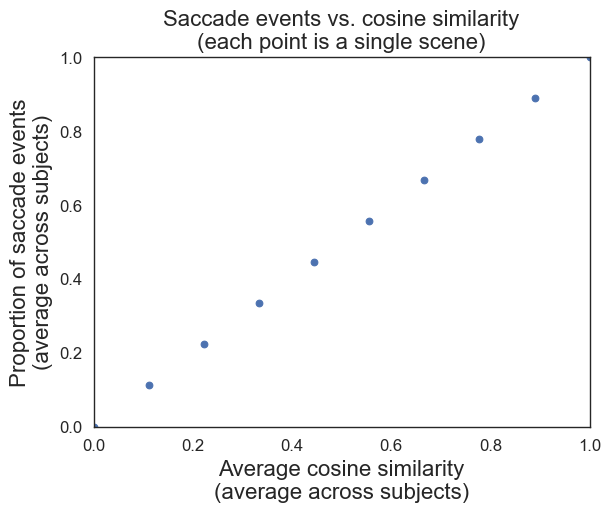

In [ ]:
xs = np.linspace(0, 1, 10)
ys = np.linspace(0, 1, 10)

plt.scatter(xs, ys)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Saccade events vs. cosine similarity\n(each point is a single scene)')
plt.xlabel('Average cosine similarity\n(average across subjects)')
plt.ylabel('Proportion of saccade events\n(average across subjects)')
plt.show()

In [132]:
classified_trial_data.head()

,subject_id,scene_name,normalized_time,segment_class,x,y,pupil,path_condition,raw_time,trial,x_int,y_int
0,1d4c760f,high_nocol_nosp_1,0,fixation,715.9,440.5,1847.0,no_straight_path,0.000,reasoning,715,440
1,1d4c760f,high_nocol_nosp_1,1,fixation,705.8,452.2,1848.0,no_straight_path,0.001,reasoning,705,452
2,1d4c760f,high_nocol_nosp_1,2,fixation,696.5,465.2,1850.0,no_straight_path,0.002,reasoning,696,465
3,1d4c760f,high_nocol_nosp_1,3,fixation,687.4,478.0,1853.0,no_straight_path,0.003,reasoning,687,478
4,1d4c760f,high_nocol_nosp_1,4,fixation,679.5,490.9,1854.0,no_straight_path,0.004,reasoning,679,490


In [43]:
df2 = model_predictions.rename(columns={'sample_idx': 'subject_id'})
df2 = df2.groupby(
    ['scene_name', 'segment_class']).size().reset_index(name='count')
df=classified_trial_data[
    classified_trial_data.segment_class.isin(['saccade', 'smooth_pursuit'])
].groupby(['scene_name', 'segment_class']).size().reset_index(name='count')
saccade_props_1 = (
    df[df['segment_class'] == 'saccade']
    .groupby('scene_name')['count']
    .sum()
    / df.groupby('scene_name')['count'].sum()
).reset_index()
saccade_props_2 = (
    df2[df2['segment_class'] == 'abstraction']
    .groupby('scene_name')['count']
    .sum()
    / df2.groupby('scene_name')['count'].sum()
).reset_index()
saccade_props_2.head()
saccade_props_2.rename(columns={'count': 'abstraction_count'}, inplace=True)
saccade_props_2.head()
saccade_props_1.rename(columns={'count': 'saccade_count'}, inplace=True)
saccade_props_1.head()
saccade_props = saccade_props_1.merge(saccade_props_2, on='scene_name', how='left')
saccade_props.head()

,scene_name,saccade_count,abstraction_count
0,high_nocol_nosp_1,0.675820,0.192308
1,high_nocol_nosp_2,0.698665,0.244186
2,high_nocol_nosp_3,0.750272,0.222222
3,high_nocol_nosp_4,0.656935,0.288889
4,high_nocol_yessp_1,0.670452,0.384127


r-value: 0.3213
p-value: 0.0007845


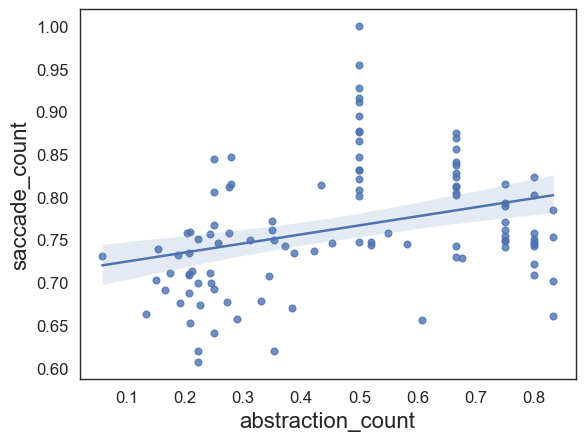

In [46]:
sns.regplot(
    data=saccade_props,
    y='saccade_count',
    x='abstraction_count',
    # hue='scene_name',
    # palette=GAZE_CLASS_COLORS,
)
from scipy.stats import pearsonr
r_value, p_value = pearsonr(saccade_props['saccade_count'], saccade_props['abstraction_count'])
print(f"r-value: {r_value:.4g}")
print(f"p-value: {p_value:.4g}")

# Plot gaze data

In [ ]:
# Compute per-subject proportion of each segment class by path condition
_counts = (
    classified_trial_data[
        classified_trial_data.segment_class.isin(['saccade', 'smooth_pursuit'])
    ]
    .groupby(['subject_id', 'path_condition', 'segment_class'])
    .size()
    .reset_index(name='count')
)
_totals = _counts.groupby(['subject_id', 'path_condition'])['count'].transform('sum')
per_subject_class_prop = _counts.copy()
per_subject_class_prop['proportion'] = _counts['count'] / _totals

# Rename columns for the Mann-Whitney U test cells
proportion_df = per_subject_class_prop.rename(columns={
    'path_condition': 'path',
    'segment_class': 'class'
})

# Compute gaze movement magnitude and direction from consecutive gaze points
_gaze = classified_trial_data.sort_values(['subject_id', 'scene_name', 'normalized_time']).copy()
_gaze['dx'] = _gaze.groupby(['subject_id', 'scene_name'])['x'].diff()
_gaze['dy'] = _gaze.groupby(['subject_id', 'scene_name'])['y'].diff()
_gaze = _gaze.dropna(subset=['dx', 'dy'])
_gaze['magnitude'] = np.sqrt(_gaze['dx']**2 + _gaze['dy']**2)
_gaze['direction'] = np.degrees(np.arctan2(_gaze['dy'], _gaze['dx'])) % 360
gaze_movement_data = _gaze[['subject_id', 'scene_name', 'path_condition', 'magnitude', 'direction']].copy()
gaze_movement_data = gaze_movement_data.rename(columns={'path_condition': 'path'})

Text(0.5, 1.0, 'Proportion of saccade labels\nby path condition')

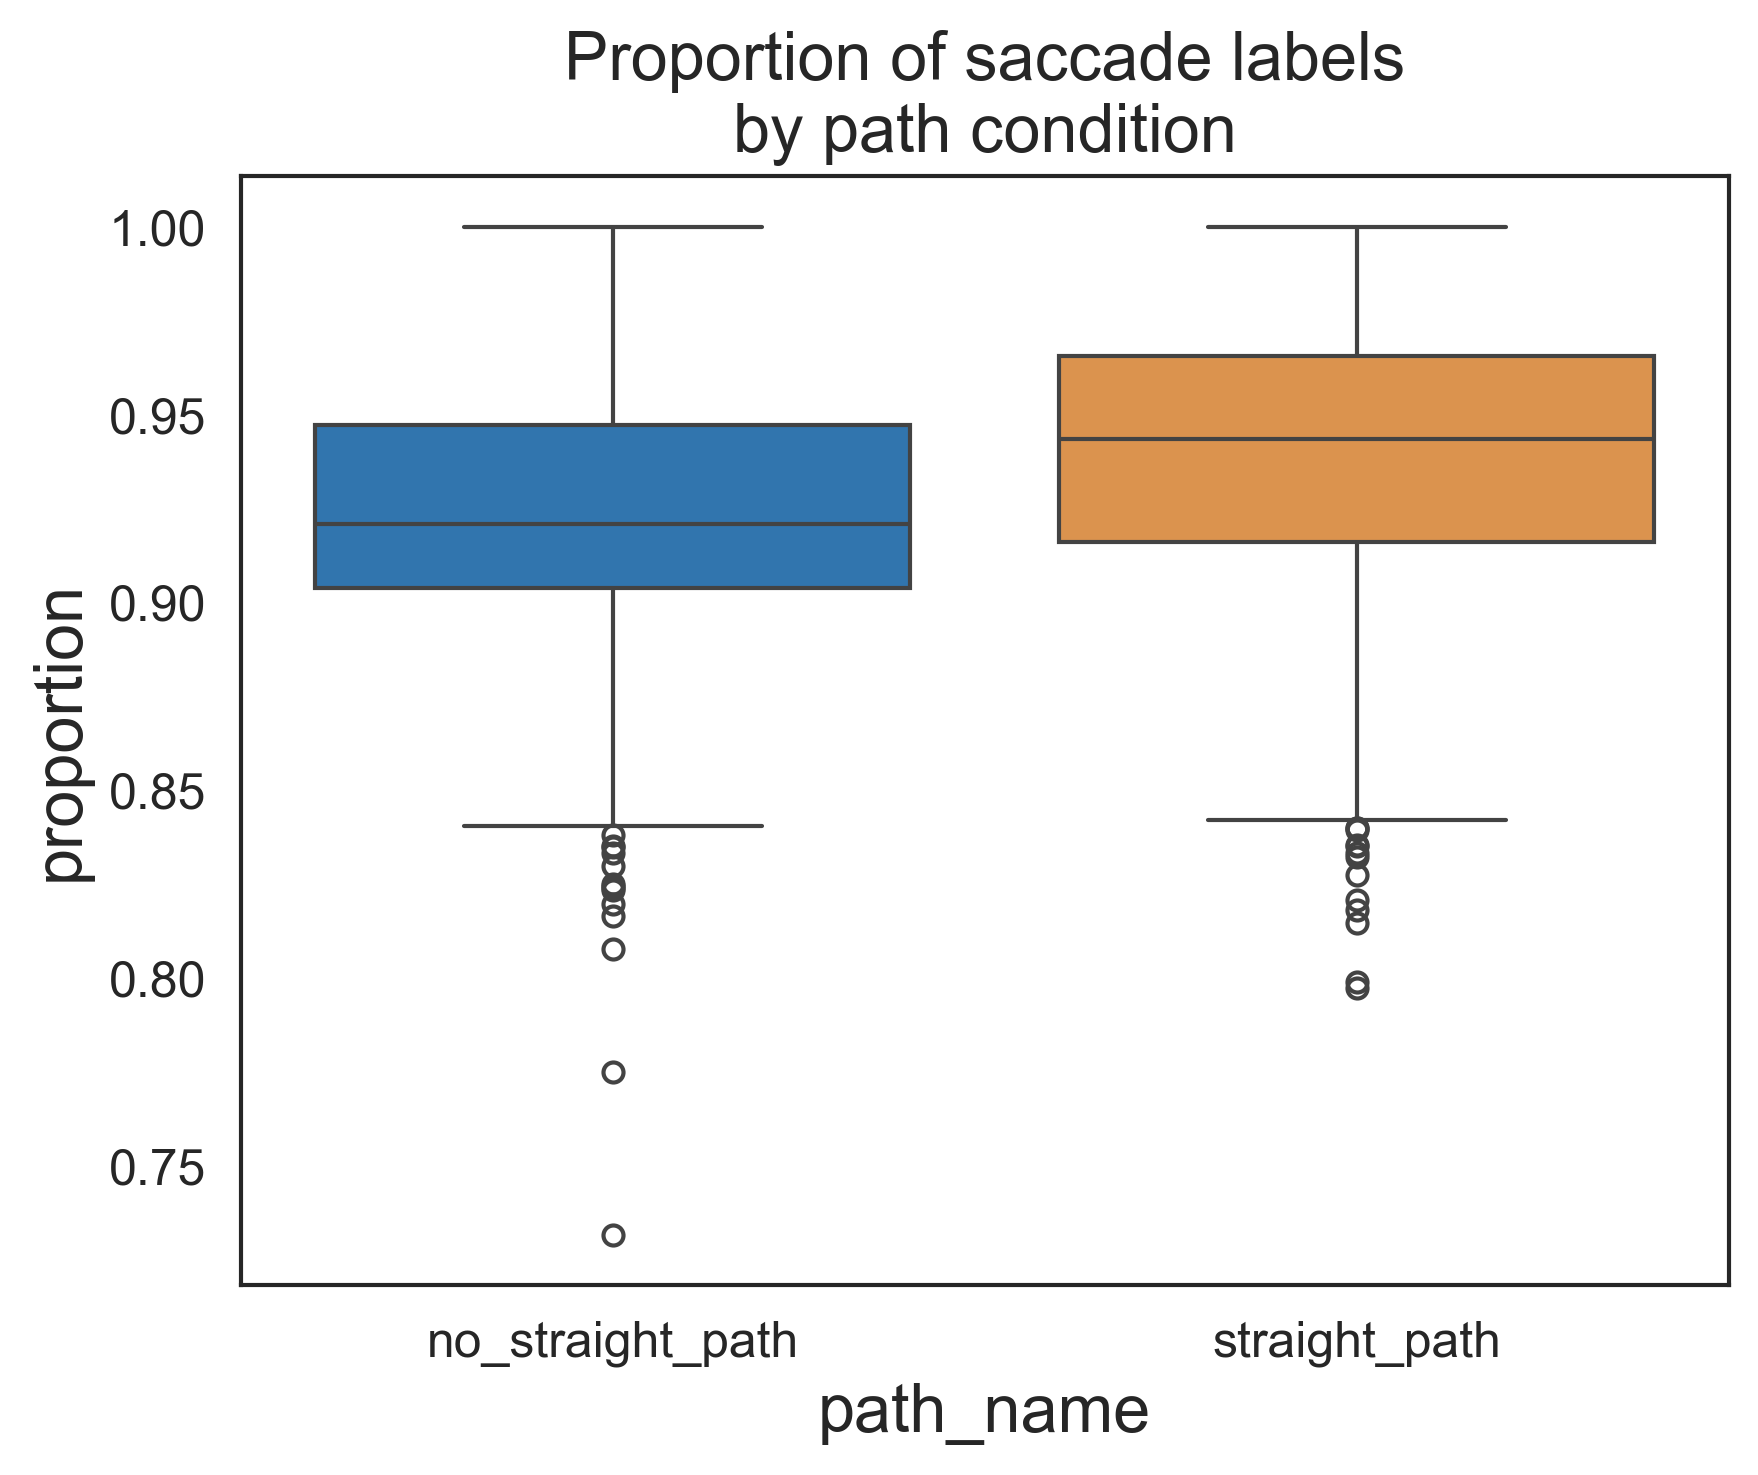

In [ ]:
g = sns.boxplot(
    data=per_subject_class_prop[
        per_subject_class_prop['segment_class'] == 'saccade'
    ],
    x='path_condition',
    y='proportion',
    hue='path_condition',
    palette=PATH_PALETTE,
)
g.set_title('Proportion of saccade labels\nby path condition')

Text(0.5, 1.0, 'Proportion of smooth pursuit labels\nby path condition')

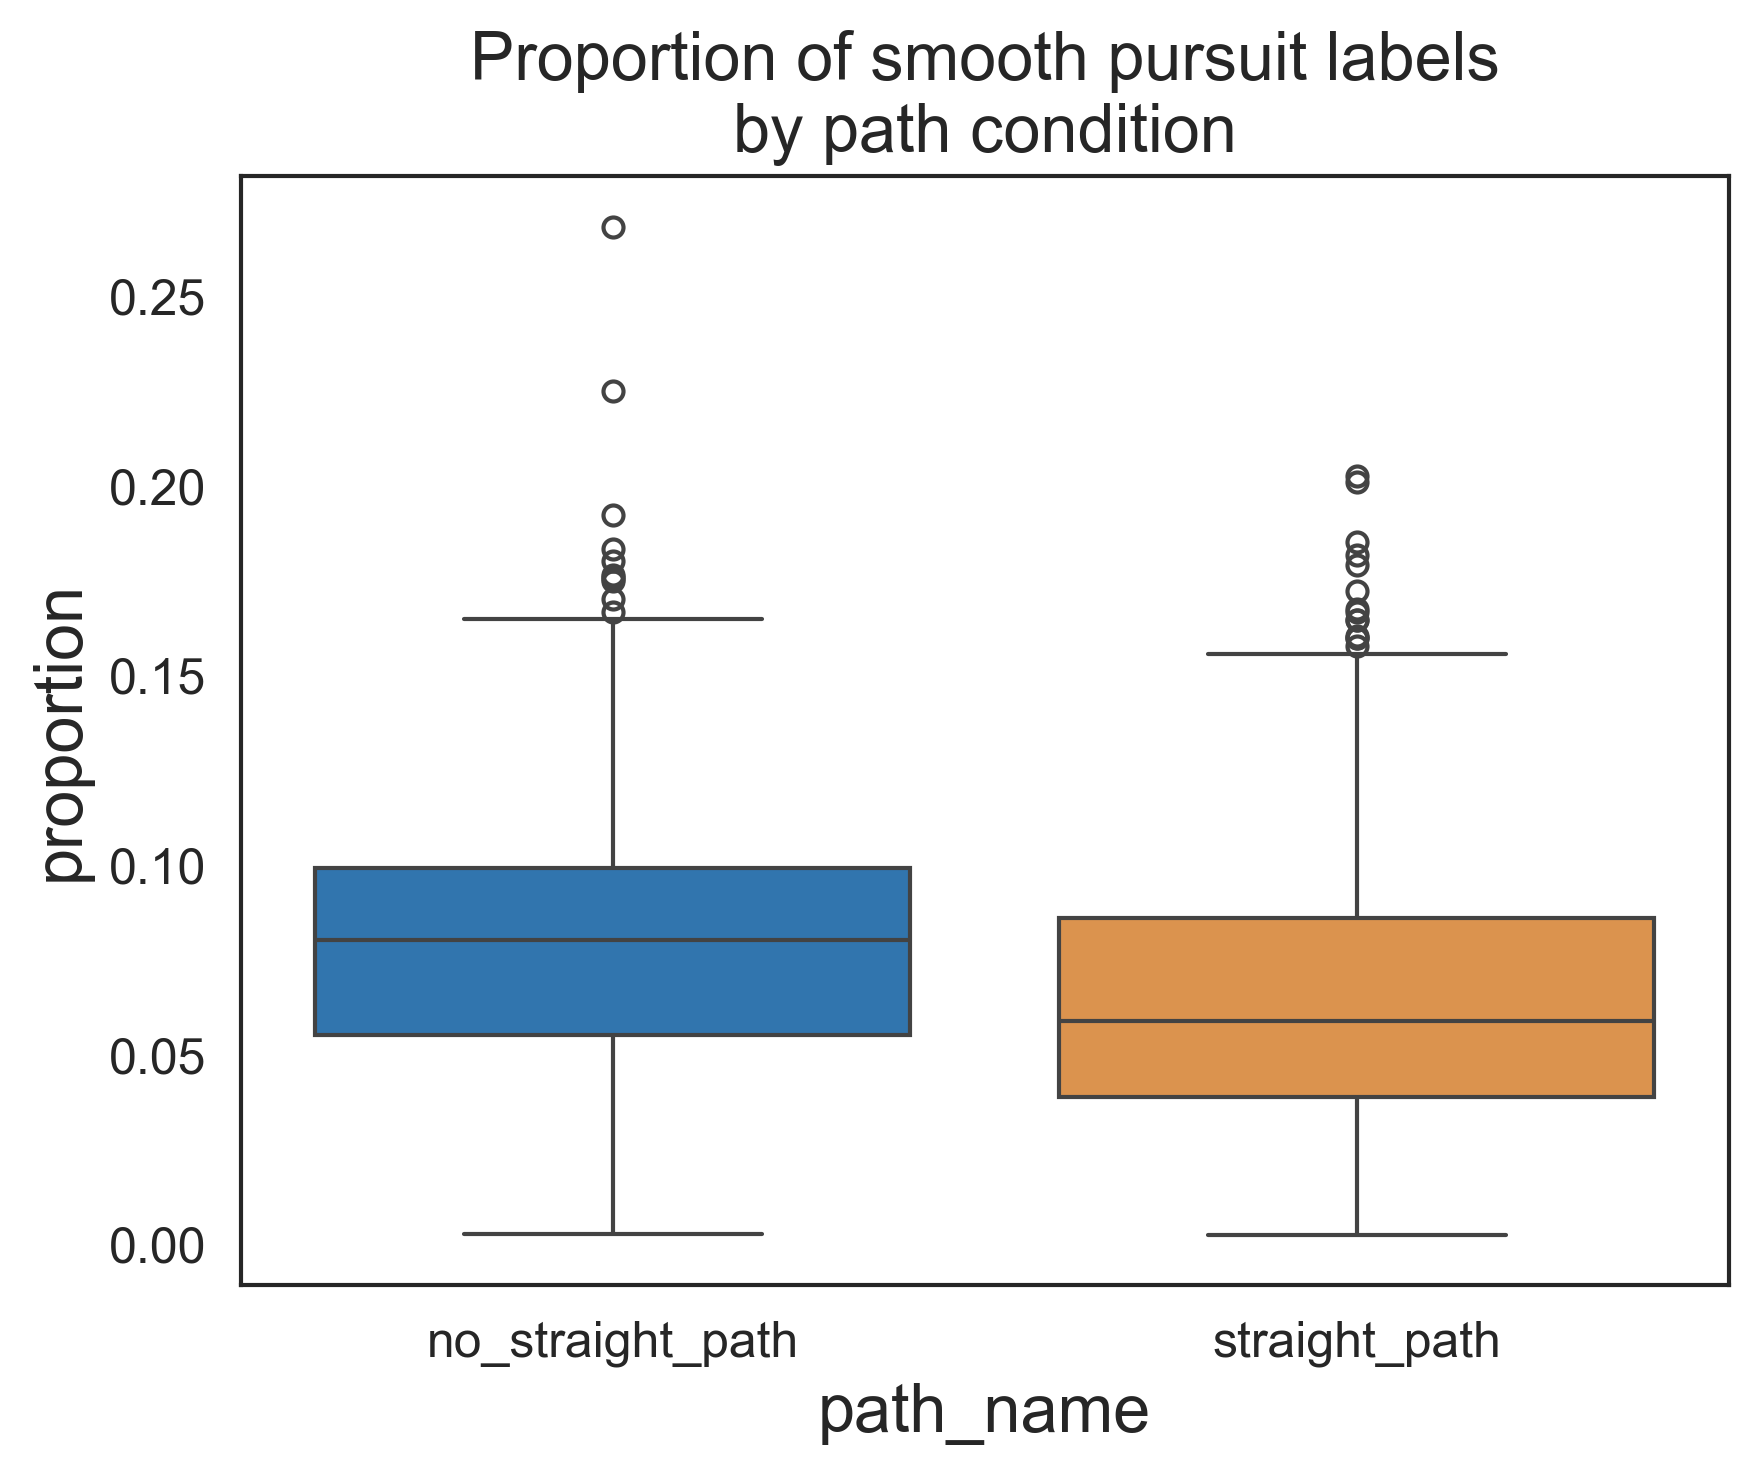

In [ ]:
g = sns.boxplot(
    data=per_subject_class_prop[
        per_subject_class_prop['segment_class'] == 'smooth_pursuit'
    ],
    x='path_condition',
    y='proportion',
    hue='path_condition',
    palette=PATH_PALETTE,
)
g.set_title('Proportion of smooth pursuit labels\nby path condition')
# plt.tight_layout()
# plt.savefig(f'../{config.DATA_DIR}/figures/gaze_label_proportions.pdf', dpi=300)
# plt.show()

In [25]:
# Perform Mann-Whitney U test to compare segment class counts between path conditions
from scipy.stats import mannwhitneyu, shapiro
# Filter data for the two path conditions we want to compare
straight_path_data = proportion_df[proportion_df['path'] == 'straight_path']
no_straight_path_data = proportion_df[proportion_df['path'] == 'no_straight_path']
# Initialize results dictionary
mw_results = {}
normality_results = {}
# Perform test for each class
for cls in proportion_df['class'].unique():
    straight_counts = straight_path_data[straight_path_data['class'] == cls]['proportion']
    no_straight_counts = no_straight_path_data[no_straight_path_data['class'] == cls]['proportion']
    # Only perform test if we have data for both conditions
    if len(straight_counts) > 0 and len(no_straight_counts) > 0:
        # Test for normality using Shapiro-Wilk test
        _, p_straight = shapiro(straight_counts)
        _, p_no_straight = shapiro(no_straight_counts)
        is_normal = (p_straight > 0.05) and (p_no_straight > 0.05)
        normality_results[cls] = {
            'straight_path_normal': p_straight > 0.05,
            'no_straight_path_normal': p_no_straight > 0.05,
            'both_normal': is_normal,
            'p_straight': p_straight,
            'p_no_straight': p_no_straight
        }
        
        # Perform Mann-Whitney U test (non-parametric, doesn't assume normality)
        stat, p_value = mannwhitneyu(straight_counts, no_straight_counts)
        mw_results[cls] = {
            'statistic': stat,
            'p_value': p_value,
            'significant': p_value < 0.05
        }
# Display normality test results
print("Normality Test Results (Shapiro-Wilk):")
for cls, result in normality_results.items():
    print(f"Class {cls} ({LABELS.get(cls, 'Unknown')}):")
    print(f"  straight_path: p={result['p_straight']:.4f} ({'normal' if result['straight_path_normal'] else 'not normal'})")
    print(f"  no_straight_path: p={result['p_no_straight']:.4f} ({'normal' if result['no_straight_path_normal'] else 'not normal'})")
    print(f"  Overall: {'Both normal' if result['both_normal'] else 'Not both normal'}")

# Display Mann-Whitney U test results
print("\nMann-Whitney U Test Results (straight_path vs no_straight_path):")
for cls, result in mw_results.items():
    print(f"Class {cls} ({LABELS.get(cls, 'Unknown')}): U={result['statistic']:.2f}, p={result['p_value']:.4f} {'*' if result['significant'] else ''}")

Normality Test Results (Shapiro-Wilk):
Class 1 (Fixation):
  straight_path: p=0.0000 (not normal)
  no_straight_path: p=0.0000 (not normal)
  Overall: Not both normal
Class 2 (Saccade):
  straight_path: p=0.0000 (not normal)
  no_straight_path: p=0.0030 (not normal)
  Overall: Not both normal
Class 4 (Smooth Pursuit):
  straight_path: p=0.0000 (not normal)
  no_straight_path: p=0.0000 (not normal)
  Overall: Not both normal
Class 3 (PSO):
  straight_path: p=0.0000 (not normal)
  no_straight_path: p=0.0000 (not normal)
  Overall: Not both normal

Mann-Whitney U Test Results (straight_path vs no_straight_path):
Class 1 (Fixation): U=82927.00, p=0.0130 *
Class 2 (Saccade): U=141127.50, p=0.0000 *
Class 4 (Smooth Pursuit): U=79428.50, p=0.0000 *
Class 3 (PSO): U=74650.50, p=0.0000 *


...

Mann-Whitney U Test: U=1.83e+12, p=0.0000


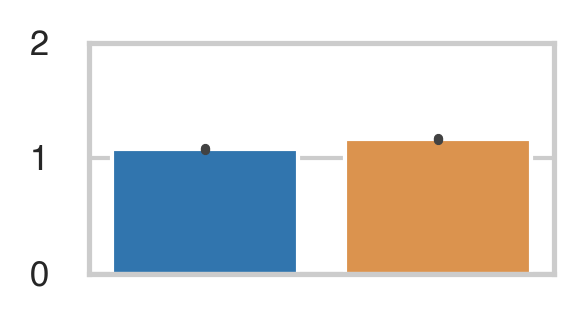

In [677]:
# g = sns.FacetGrid(gaze_movement_data.query("scene_name == 'high_nocol_nosp_1'"), col='path', col_wrap=2, height=4, aspect=1.2, sharex=True, sharey=False)
# Perform Mann-Whitney U test to see if magnitude distributions differ between path types
straight_path_magnitudes = gaze_movement_data[gaze_movement_data['path'] == 'straight_path']['magnitude']
no_straight_path_magnitudes = gaze_movement_data[gaze_movement_data['path'] == 'no_straight_path']['magnitude']
# Run the test
mwu_stat, p_value = mannwhitneyu(straight_path_magnitudes, no_straight_path_magnitudes)
print(f"Mann-Whitney U Test: U={mwu_stat:.2e}, p={p_value:.4f}")

sns.set_theme(
    style='whitegrid',
    font_scale=0.75,
    rc={
        'figure.dpi':300,
        'font.family':'sans-serif',
        'font.sans-serif':['Helvetica'],
        'figure.figsize':(2,1),
    },
)
# Create the plot
ax=sns.barplot(data=gaze_movement_data, x='path', y='magnitude', hue='path', palette=PATH_PALETTE)
ax.set_xticklabels([])
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(0, 2)

plt.savefig(os.path.join('..', config.FIGURE_STORE, 'gaze_magnitude.pdf'), bbox_inches='tight')

<Figure size 600x450 with 0 Axes>

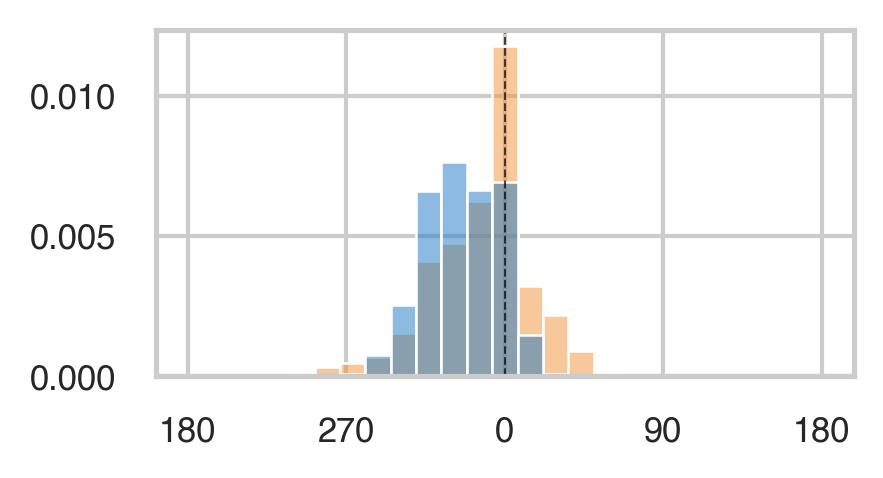

In [684]:
# Create a custom histogram with 360 in the middle
# First, shift the data to center around 360
shifted_data = gaze_movement_data.copy()
shifted_data['shifted_direction'] = (shifted_data['direction'] + 180) % 360

# Create the plot with the shifted data
ax = sns.histplot(data=shifted_data, x='shifted_direction', hue='path', palette=PATH_PALETTE, stat='density', legend=False, bins=25)

sns.set_theme(
    style='whitegrid',
    font_scale=1,
    rc={
        'figure.dpi':300,
        'font.family':'sans-serif',
        'font.sans-serif':['Helvetica'],
        'figure.figsize':(3,1.5),
    },
)
# Customize x-axis ticks to show original values
ticks = np.arange(0, 361, 90)  # 0, 45, 90, ..., 360
labels = [(t + 180) % 360 for t in ticks]  # Shift back for display
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_xlabel('')
ax.set_ylabel('')
# Add a vertical line at 180 (which is 360 in the original scale)
plt.axvline(x=180, color='black', linestyle='--', alpha=0.7, linewidth=0.5)
plt.savefig(os.path.join('..', config.FIGURE_STORE, 'gaze_direction.pdf'), bbox_inches='tight')

In [598]:
# g = sns.FacetGrid(gaze_movement_data.query("scene_name == 'high_nocol_nosp_1'"), col='path', col_wrap=2, height=4, aspect=1.2, sharex=True, sharey=False)
# Perform Mann-Whitney U test to see if magnitude distributions differ between path types
straight_path_directions = gaze_movement_data[gaze_movement_data['path'] == 'straight_path']['direction']
no_straight_path_directions = gaze_movement_data[gaze_movement_data['path'] == 'no_straight_path']['direction']
# Run the test
mwu_stat, p_value = mannwhitneyu(straight_path_directions, no_straight_path_directions)
print(f"Mann-Whitney U Test: U={mwu_stat:.2e}, p={p_value:.4f}")

Mann-Whitney U Test: U=1.60e+12, p=0.0000


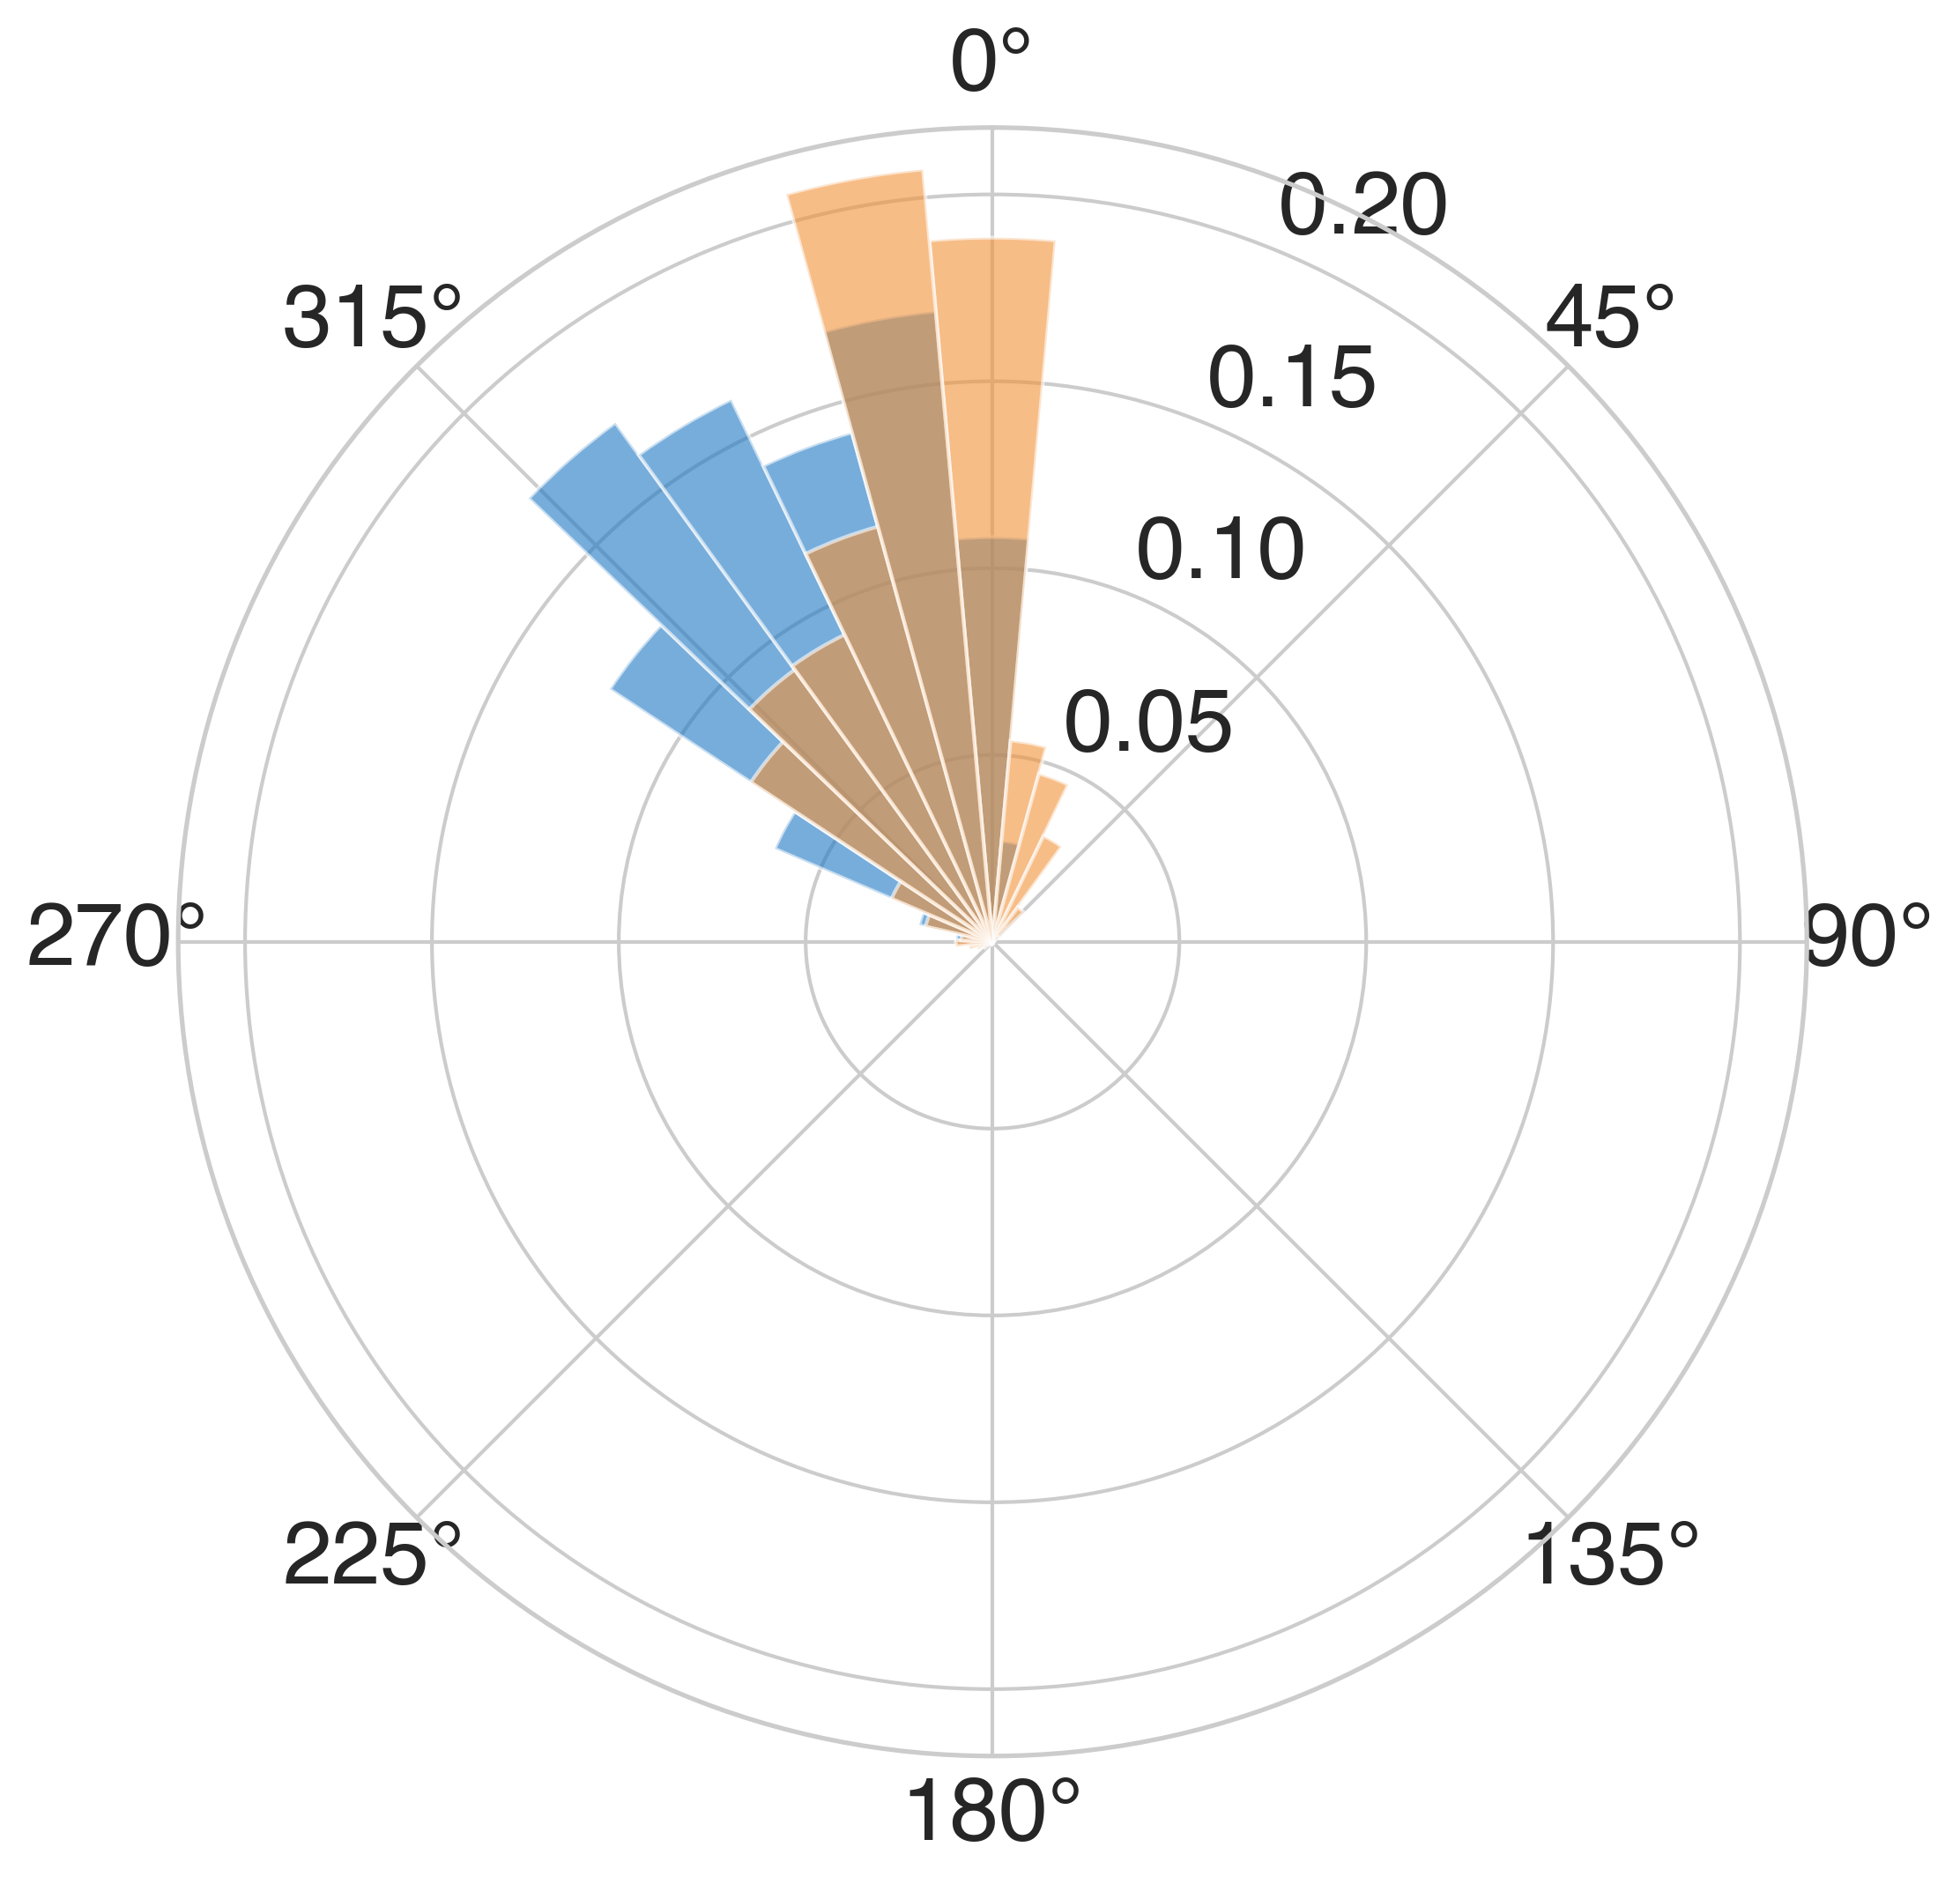

In [694]:
# Convert direction from degrees to radians for polar plotting
directions_rad = np.deg2rad(gaze_movement_data['direction'])

# Create a figure with polar projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': 'polar'})

# Create histogram bins for the polar plot
bins = np.linspace(0, 2*np.pi, 36)  # 36 bins for 10-degree intervals

# Plot histogram for each path type
for path_type in gaze_movement_data['path'].unique():
    path_directions = directions_rad[gaze_movement_data['path'] == path_type]
    hist, _ = np.histogram(path_directions, bins=bins)
    # Convert counts to proportions by dividing by total count
    total_count = len(path_directions)
    proportions = hist / total_count if total_count > 0 else hist
    width = (2*np.pi) / (len(bins)-1)
    bars = ax.bar(bins[:-1], proportions, width=width, alpha=0.6, label=path_type, color=PATH_PALETTE[path_type])

# Customize the plot
ax.set_theta_zero_location('N')  # 0 degrees at the top
ax.set_theta_direction(-1)  # clockwise
plt.rcParams.update({'font.size': plt.rcParams['font.size'] * 3})  # Double all font sizes

# Remove the theta ticks (degree labels)
# ax.set_xticklabels([])
# Set fewer radial ticks to reduce clutter in the concentric rings
ax.set_rticks([0.05, 0.1, 0.15, 0.20])  # Reduced number of radial ticks showing proportion values

# Apply larger font sizes to specific elements
ax.tick_params(axis='both', which='major', labelsize=24)  # Increase tick label size

plt.tight_layout()
# plt.savefig(os.path.join('..', config.FIGURE_STORE, 'gaze_angle_by_path.pdf'), dpi=300, bbox_inches='tight')

In [603]:
gaze_movement_data.path.describe()

count           3818198
unique                2
top       straight_path
freq            2014918
Name: path, dtype: object

In [430]:
trial_gaze_data.head()

,subject_id,scene_name,response_time,trial_duration,raw_time,x,y,pupil,trajectory_idx,normalized_time,path
611334,1d4c760f,high_nocol_nosp_1,5.48389,5.662,0.000,715.9,440.5,1847.0,401,0,no_straight_path
611335,1d4c760f,high_nocol_nosp_1,5.48389,5.662,0.001,705.8,452.2,1848.0,402,1,no_straight_path
611336,1d4c760f,high_nocol_nosp_1,5.48389,5.662,0.002,696.5,465.2,1850.0,403,2,no_straight_path
611337,1d4c760f,high_nocol_nosp_1,5.48389,5.662,0.003,687.4,478.0,1853.0,404,3,no_straight_path
611338,1d4c760f,high_nocol_nosp_1,5.48389,5.662,0.004,679.5,490.9,1854.0,405,4,no_straight_path
